In [2]:
# ─────────────────────────────────────────────
# 환경 준비 — 라이브러리 불러오기 + 한글 폰트 + 시드 고정
# ─────────────────────────────────────────────
# 필요 시 아래 주석을 해제해 설치하세요.
!pip install numpy pandas matplotlib seaborn pyarrow -q

import os
import platform
import time
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore")   # 학습 중 경고 메시지를 잠시 숨깁니다.

# 재현성: 같은 난수를 항상 같게 만들어 결과가 매번 동일하도록 고정합니다.
np.random.seed(42)

# 한글 폰트 설정 (그래프 안 글자가 깨지지 않도록 운영체제별로 분기)
system = platform.system()
if system == "Darwin":          # macOS
    plt.rcParams["font.family"] = "AppleGothic"
elif system == "Windows":       # Windows
    plt.rcParams["font.family"] = "Malgun Gothic"
else:                            # Linux 등
    plt.rcParams["font.family"] = "DejaVu Sans"

plt.rcParams["axes.unicode_minus"] = False
plt.rcParams["figure.figsize"] = (10, 5)
sns.set_style("whitegrid")

# 결과 저장용 임시 폴더 (이 노트북 옆에 'D009_outputs/' 가 만들어집니다)
OUT_DIR = Path("D009_outputs")
OUT_DIR.mkdir(exist_ok=True)

print("준비 완료! 라이브러리 버전을 확인합니다.")
print("numpy :", np.__version__)
print("pandas:", pd.__version__)
print("저장 폴더:", OUT_DIR.resolve())

준비 완료! 라이브러리 버전을 확인합니다.
numpy : 2.4.6
pandas: 3.0.3
저장 폴더: C:\Users\USER\ai-data-bootcamp\D009\d009_outputs


In [3]:
# 종합 프로젝트용 새 데이터 생성 — 베이커리 체인 "빵셀러" 운영 데이터
np.random.seed(13)
n_days = 90
n_stores = 6
n_rows = n_days * n_stores * 4   # 매장 x 일자 x 시간대(4구간)

stores = [f"S{i:02d}" for i in range(1, n_stores + 1)]
items = ["크루아상", "식빵", "케이크", "샌드위치", "쿠키"]

bakery = pd.DataFrame({
    "store_id": np.tile(stores, n_rows // n_stores)[:n_rows],
    "date_str": np.random.choice([
        "2025-04-01", "2025/04/01", "20250401",
        "2025-05-15", "2025/05/15", "20250515",
        "2025-06-20", "2025/06/20", "20250620",
    ], n_rows),
    "item": np.random.choice(items, n_rows),
    "quantity": np.random.choice([1, 1, 2, 2, 3, 5, 50], n_rows),  # 50은 의심값
    "unit_price": np.random.choice([3500, 4500, 5500, 8500, 12000], n_rows),
})
bakery["revenue"] = bakery["quantity"] * bakery["unit_price"]

# 오염 심기
bakery.loc[np.random.choice(n_rows, 60, replace=False), "revenue"] = np.nan
bakery.loc[5, "revenue"] = -45000  # 환불 또는 실수
bakery.loc[bakery.sample(10, random_state=1).index, "store_id"] = " S01 "  # 공백
bakery.loc[bakery.sample(8, random_state=2).index, "item"] = "케익"        # 표기 혼재('케이크' vs '케익')
bakery = pd.concat([bakery, bakery.iloc[[0, 1, 2, 3]]], ignore_index=True)   # 중복 4건

print("빵셀러 데이터 생성 완료:", bakery.shape)
bakery.head()

빵셀러 데이터 생성 완료: (2164, 6)


,store_id,date_str,item,quantity,unit_price,revenue
0,S01,20250401,쿠키,2,12000,24000.0
1,S02,2025-04-01,케이크,2,12000,24000.0
2,S03,2025-04-01,쿠키,1,5500,5500.0
3,S04,2025-06-20,쿠키,2,8500,17000.0
4,S05,20250401,샌드위치,5,4500,22500.0


In [4]:
# 예제: 품질 리포트 함수 v1 — 결측·중복·타입을 한 번에 보여주는 진단기
def quality_report(df: pd.DataFrame, name: str = "df") -> pd.DataFrame:
    '''데이터프레임의 품질을 컬럼별로 진단해 한 표로 돌려줍니다.'''
    n_rows = len(df)
    report = pd.DataFrame({
        "dtype": df.dtypes.astype(str),
        "missing": df.isna().sum(),
        "missing_pct": (df.isna().mean() * 100).round(2),
        "n_unique": df.nunique(dropna=True),
        "sample": [df[col].dropna().iloc[0] if df[col].notna().any() else None for col in df.columns],
    })
    print(f"[품질 리포트] {name}")
    print(f"  행 수: {n_rows:,}  /  열 수: {len(df.columns)}")
    print(f"  메모리: {df.memory_usage(deep=True).sum() / 1024:.1f} KB")
    print(f"  완전 중복 행: {df.duplicated().sum()}건")
    return report


In [5]:
# 예제: 품질 리포트 함수 v2 — 수치형 컬럼에 IQR 이상치 비율을 추가
def quality_report_full(df: pd.DataFrame, name: str = "df") -> pd.DataFrame:
    '''v1에 수치형 이상치 비율(IQR)과 의심 타입 컬럼 표시를 추가합니다.'''
    n_rows = len(df)
    base = pd.DataFrame({
        "dtype": df.dtypes.astype(str),
        "missing": df.isna().sum(),
        "missing_pct": (df.isna().mean() * 100).round(2),
        "n_unique": df.nunique(dropna=True),
    })

    # IQR 이상치 비율 (수치형 컬럼만)
    outlier_pct = {}
    for col in df.select_dtypes(include="number").columns:
        s = df[col].dropna()
        q1, q3 = s.quantile(0.25), s.quantile(0.75)
        iqr = q3 - q1
        lo, hi = q1 - 1.5 * iqr, q3 + 1.5 * iqr
        outlier_pct[col] = ((s < lo) | (s > hi)).mean() * 100
    base["outlier_pct_iqr"] = pd.Series(outlier_pct).round(2)

    # object 컬럼이 실제로는 날짜로 파싱되는지 의심 표시
    suspicious_datetime = []
    for col in df.select_dtypes(include="object").columns:
        try:
            parsed = pd.to_datetime(df[col], errors="coerce")
            if parsed.notna().mean() > 0.8:
                suspicious_datetime.append(col)
        except Exception:
            pass
    base["maybe_datetime"] = base.index.isin(suspicious_datetime)

    print(f"[품질 리포트(완전판)] {name}")
    print(f"  행 수: {n_rows:,}  /  열 수: {len(df.columns)}")
    print(f"  완전 중복 행: {df.duplicated().sum()}건")
    if suspicious_datetime:
        print(f"  📌 날짜로 보이는 object 컬럼: {suspicious_datetime}")
    return base


In [6]:
qr_bakery = quality_report_full(bakery, "bakery")
qr_bakery

[품질 리포트(완전판)] bakery
  행 수: 2,164  /  열 수: 6
  완전 중복 행: 321건


,dtype,missing,missing_pct,n_unique,outlier_pct_iqr,maybe_datetime
store_id,str,0,0.00,7,NaN,False
date_str,str,0,0.00,9,NaN,False
item,str,0,0.00,6,NaN,False
quantity,int64,0,0.00,5,14.56,False
unit_price,int64,0,0.00,5,0.00,False
revenue,float64,60,2.77,26,17.30,False


In [7]:
def b_dedup(df): return df.drop_duplicates().reset_index(drop=True)
def b_strip_store(df): return df.assign(store_id=df["store_id"].str.strip())
def b_unify_item(df): return df.assign(item=df["item"].replace({"케익": "케이크"}))
def b_parse_date(df): return df.assign(
    date=pd.to_datetime(df["date_str"], format="mixed", errors="coerce")
).drop(columns=["date_str"])

refunds_bakery = bakery[bakery["revenue"] < 0].copy()

bakery_clean = (
    bakery
    .pipe(b_dedup)
    .pipe(b_strip_store)
    .pipe(b_unify_item)
    .pipe(b_parse_date)
    .pipe(lambda d: d[d["revenue"] >= 0])    # 환불 분리 후 본 분석에서 제외
    .pipe(lambda d: d.dropna(subset=["revenue"]))
    .reset_index(drop=True)
)

print(f"정제 전: {bakery.shape}  →  정제 후: {bakery_clean.shape}")
print(f"환불 보관: {len(refunds_bakery)}건")
print(f"item 종류: {bakery_clean['item'].unique()}")

정제 전: (2164, 6)  →  정제 후: (1784, 6)
환불 보관: 1건
item 종류: <ArrowStringArray>
['쿠키', '케이크', '샌드위치', '크루아상', '식빵']
Length: 5, dtype: str


In [8]:
# KPI 1: 월별·매장별 매출 합계 (wide)
bakery_clean["month"] = bakery_clean["date"].dt.to_period("M").astype(str)
store_month = (
    bakery_clean.groupby(["store_id", "month"])["revenue"].sum().unstack(fill_value=0).round(0)
)
print("월별·매장별 매출:")
display(store_month)

# KPI 2: 상품별 평균 단가·총매출
item_kpi = (
    bakery_clean.groupby("item")
    .agg(avg_price=("unit_price", "mean"), total_revenue=("revenue", "sum"), n_orders=("revenue", "count"))
    .round(0)
    .sort_values("total_revenue", ascending=False)
)
print("\n상품별 KPI:")
display(item_kpi)

# Parquet 저장
store_month.to_parquet(OUT_DIR / "bakery_store_month.parquet")
item_kpi.to_parquet(OUT_DIR / "bakery_item_kpi.parquet")
print(f"\nParquet 저장 완료: {OUT_DIR.resolve()}")

월별·매장별 매출:


month,2025-04,2025-05,2025-06
store_id,,,
S01,6834000.0,7243500.0,5884000.0
S02,7531500.0,6768500.0,7996500.0
S03,7424500.0,4548000.0,7297500.0
S04,6471500.0,7105000.0,6744500.0
S05,8681500.0,4102000.0,4960000.0
S06,9156000.0,5095500.0,6796500.0



상품별 KPI:


,avg_price,total_revenue,n_orders
item,,,
쿠키,6878.0,26690000.0,365
샌드위치,6555.0,26297000.0,370
케이크,6859.0,23788500.0,359
식빵,6555.0,22997500.0,355
크루아상,6946.0,20867500.0,335



Parquet 저장 완료: C:\Users\USER\ai-data-bootcamp\D009\d009_outputs


In [9]:
# 예제: 결정 로그를 리스트로 누적하다가 마지막에 표로 출력
decisions = []


def log_decision(step: str, action: str, reason: str, result: str):
    decisions.append({"step": step, "action": action, "reason": reason, "result": result})


log_decision("1. 중복 제거", "완전 중복 행 drop",
             "동일 행 반복은 입력 오류로 간주", "중복 4건 제거")
log_decision("2. store_id 공백 정제", "str.strip()",
             "' S01 '과 'S01'은 같은 매장", "공백 제거로 매장 통일")
log_decision("3. item 표기 통일", "'케익'→'케이크' replace",
             "표기 혼재는 집계를 쪼갬", "item 종류 통일")
log_decision("4. 날짜 파싱", "date_str→datetime (format='mixed')",
             "월별 집계에 datetime 필요", "혼합 포맷 파싱")
log_decision("5. 환불·결측 처리", "음수 revenue 분리 + 결측 행 제거",
             "매출 분석 목적, 환불은 별도 보관",
             f"환불 {len(refunds_bakery)}건 분리")
             
decision_log = pd.DataFrame(decisions)
decision_log

,step,action,reason,result
0,1. 중복 제거,완전 중복 행 drop,동일 행 반복은 입력 오류로 간주,중복 4건 제거
1,2. store_id 공백 정제,str.strip(),' S01 '과 'S01'은 같은 매장,공백 제거로 매장 통일
2,3. item 표기 통일,'케익'→'케이크' replace,표기 혼재는 집계를 쪼갬,item 종류 통일
3,4. 날짜 파싱,date_str→datetime (format='mixed'),월별 집계에 datetime 필요,혼합 포맷 파싱
4,5. 환불·결측 처리,음수 revenue 분리 + 결측 행 제거,"매출 분석 목적, 환불은 별도 보관",환불 1건 분리


In [10]:
# 예제: 결정 로그를 마크다운 표로 출력해 노트북 끝(또는 별도 파일)에 박기
md_table = "| 단계 | 액션 | 근거 | 결과 |\n|---|---|---|---|\n"
for d in decisions:
    md_table += f"| {d['step']} | {d['action']} | {d['reason']} | {d['result']} |\n"

print(md_table)

| 단계 | 액션 | 근거 | 결과 |
|---|---|---|---|
| 1. 중복 제거 | 완전 중복 행 drop | 동일 행 반복은 입력 오류로 간주 | 중복 4건 제거 |
| 2. store_id 공백 정제 | str.strip() | ' S01 '과 'S01'은 같은 매장 | 공백 제거로 매장 통일 |
| 3. item 표기 통일 | '케익'→'케이크' replace | 표기 혼재는 집계를 쪼갬 | item 종류 통일 |
| 4. 날짜 파싱 | date_str→datetime (format='mixed') | 월별 집계에 datetime 필요 | 혼합 포맷 파싱 |
| 5. 환불·결측 처리 | 음수 revenue 분리 + 결측 행 제거 | 매출 분석 목적, 환불은 별도 보관 | 환불 1건 분리 |



In [22]:
print(bakery)

# 범주형(값 종류 적음)만 value_counts
cat_cols = ["store_id", "item", "quantity", "unit_price"]
for col in cat_cols:
    print(f"===== [{col}] =====")
    print(bakery[col].value_counts())
    print()

# 수치형(값 종류 많음)은 describe로 요약
print(bakery[["revenue"]].describe())

     store_id    date_str  item  quantity  unit_price  revenue
0         S01    20250401    쿠키         2       12000  24000.0
1         S02  2025-04-01   케이크         2       12000  24000.0
2         S03  2025-04-01    쿠키         1        5500   5500.0
3         S04  2025-06-20    쿠키         2        8500  17000.0
4         S05    20250401  샌드위치         5        4500  22500.0
...       ...         ...   ...       ...         ...      ...
2159      S06  2025/04/01  크루아상         5        8500  42500.0
2160      S01    20250401    쿠키         2       12000  24000.0
2161      S02  2025-04-01   케이크         2       12000  24000.0
2162      S03  2025-04-01    쿠키         1        5500   5500.0
2163      S04  2025-06-20    쿠키         2        8500  17000.0

[2164 rows x 6 columns]
===== [store_id] =====
store_id
S02      361
S04      361
S01      360
S03      358
S05      357
S06      357
 S01      10
Name: count, dtype: int64

===== [item] =====
item
쿠키      446
샌드위치    443
식빵      435
케이크     4

In [24]:
import matplotlib.pyplot as plt

plt.rcParams["font.family"] = "Malgun Gothic"   # Windows 기본 한글 폰트
plt.rcParams["axes.unicode_minus"] = False       # 마이너스(-) 기호 깨짐 방지

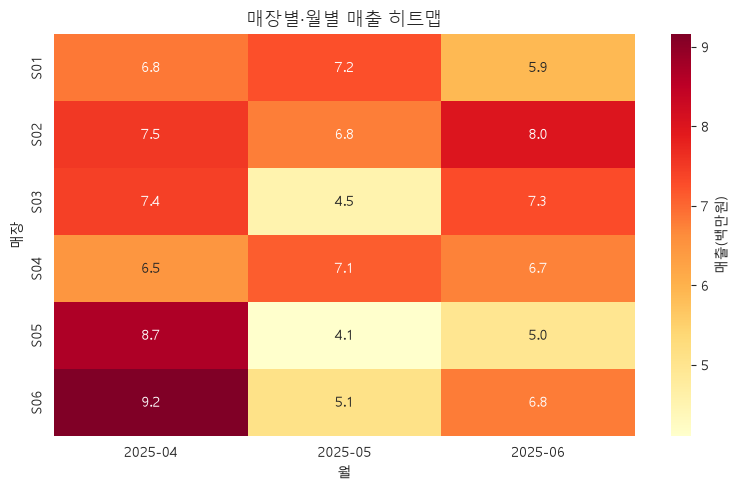

In [25]:
import seaborn as sns

fig, ax = plt.subplots(figsize=(8, 5))
sns.heatmap(
    store_month / 1e6,        # 백만원 단위로 (숫자 짧게)
    annot=True, fmt=".1f",    # 각 칸에 값 표시, 소수 1자리
    cmap="YlOrRd",            # 낮음(연노랑)→높음(진빨강)
    cbar_kws={"label": "매출(백만원)"},
    ax=ax,
)
ax.set_title("매장별·월별 매출 히트맵", fontsize=13)
ax.set_xlabel("월"); ax.set_ylabel("매장")
plt.tight_layout()
plt.show()

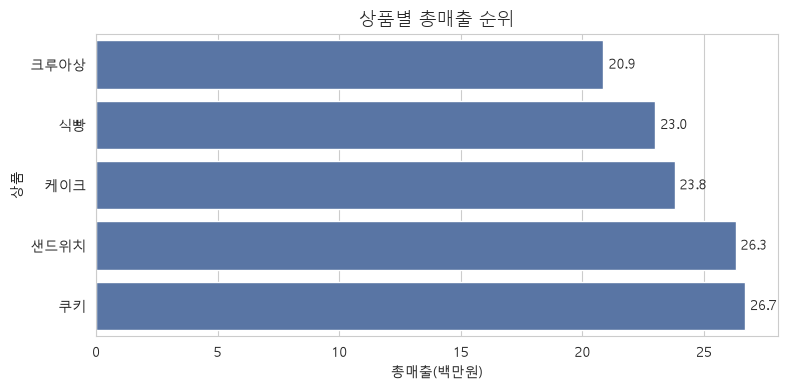

In [ ]:
# item_kpi가 이미 total_revenue 기준 정렬돼 있음 → 그대로 활용
item_sorted = item_kpi["total_revenue"].sort_values()   # 가로막대는 오름차순이 보기 좋음

fig, ax = plt.subplots(figsize=(8, 4))
sns.barplot(
    x=item_sorted.values / 1e6,
    y=item_sorted.index,
    color="#4C72B0",
    ax=ax,
)
ax.set_title("상품별 총매출 순위", fontsize=13)
ax.set_xlabel("총매출(백만원)"); ax.set_ylabel("상품")

for i, v in enumerate(item_sorted.values / 1e6):
    ax.text(v, i, f" {v:.1f}", va="center", fontsize=10)

plt.tight_layout()
plt.show()

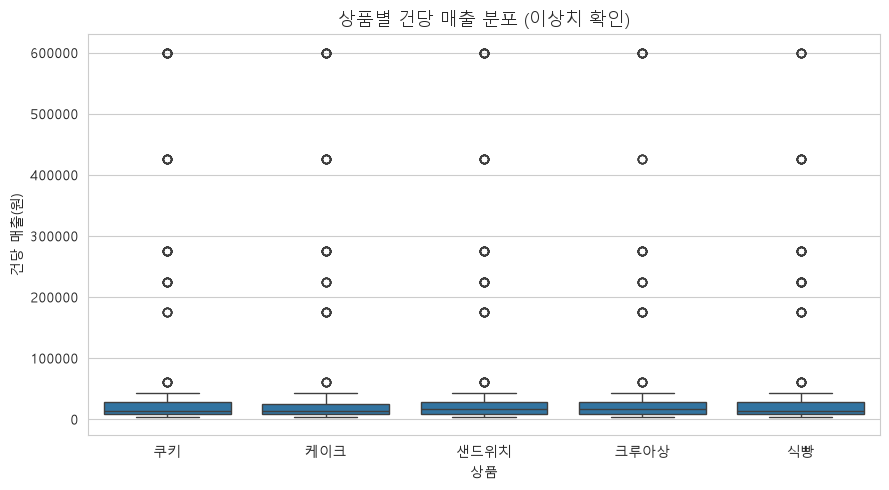

In [27]:
import seaborn as sns

fig, ax = plt.subplots(figsize=(9, 5))
sns.boxplot(
    data=bakery_clean,
    x="item", y="revenue",
    ax=ax,
)
ax.set_title("상품별 건당 매출 분포 (이상치 확인)", fontsize=13)
ax.set_xlabel("상품"); ax.set_ylabel("건당 매출(원)")
plt.tight_layout()
plt.show()

이상치 비율이 다르게 나올 수 밖에 없었던, revenue의 분포가 극단적으로 튀는 상황을 발견할 수 있었습니다.